# Carbon burning products

O/Ne white dwarfs have small amounts of Na, Mg, and other nuclei which are the products of carbon burning.

These will be the seed nuclei for the Urca process in our O/Ne white dwarfs.

Let's do a one-zone C/O burn to see what these end products are.

In [1]:
import pynucastro as pyna

The major C burning processes are:

$$\begin{split}{}^{12}\mathrm{C} + {}^{12}\mathrm{C} \rightarrow \begin{cases}
       {}^{20}\mathrm{Ne} + \alpha \\
       {}^{23}\mathrm{Na} + p \\
       {}^{23}\mathrm{Mg} + n \end{cases}
\end{split}$$

We'll include some other Ne, Na, and Mg isotopes as well.

In [2]:
net = pyna.network_helper(["p", "he4", "n",
                           "c12", "o16",
                           "ne20", "ne21", "ne22",
                           "na21", "na22", "na23",
                           "mg23", "mg24", "mg25",
                           "al27", "si28"])

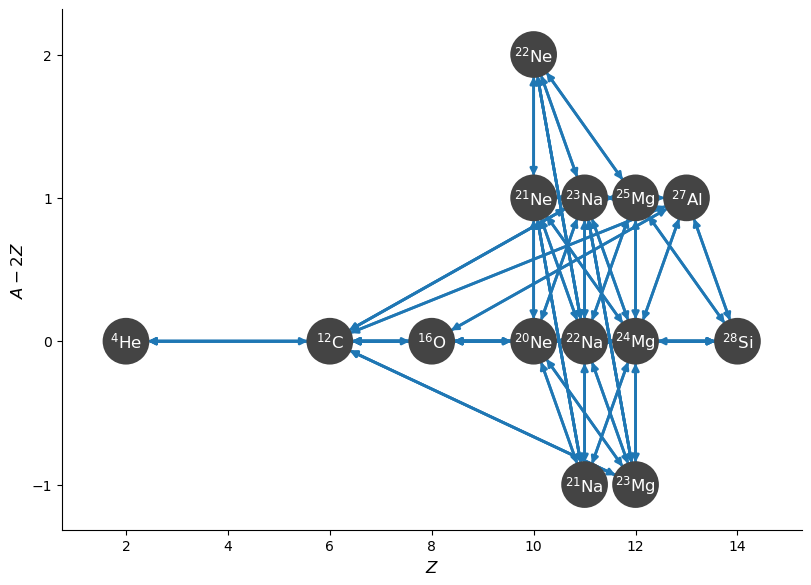

In [3]:
fig = net.plot(rotated=True)

We'll assume conditions where we expect C buring to occur.  Our results will be very sensitive to temperature.

In [4]:
comp = pyna.Composition(net.unique_nuclei)
comp.X[pyna.Nucleus("c12")] = 0.5
comp.X[pyna.Nucleus("o16")] = 0.5

In [5]:
rho = 1.e8
T = 1.e9

Now we can burn, assuming that the thermodynamic conditions are fixed.

In [6]:
tmax = 1.e5
sol = net.integrate_network(tmax, rho, T, comp.get_molar_array(), atol=1.e-10)

/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: C12 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))


/home/zingale/development/pynucastro/pynucastro/networks/python_network.py:412: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(tmin, tmax)


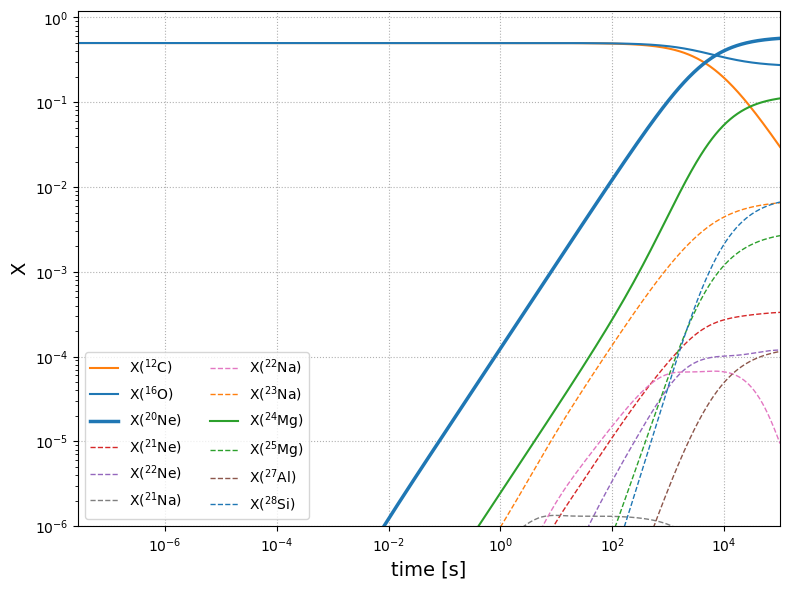

In [7]:
fig = sol.plot_evolution(three_level_style=True, ymin=1.e-6)

We can access the mass fractions at the final time (the `-1` in the temporal index)

In [8]:
X = sol.X[:, -1]
X

array([3.38751224e-22, 1.65082670e-17, 3.96382795e-12, 2.97792196e-02,
       2.74934547e-01, 5.67725355e-01, 3.32497954e-04, 1.19597671e-04,
       4.82001646e-09, 9.41848870e-06, 6.51458531e-03, 1.63783991e-09,
       1.11145073e-01, 2.66979319e-03, 1.14896355e-04, 6.65500990e-03])

We can visualize the fractions of the final composition:

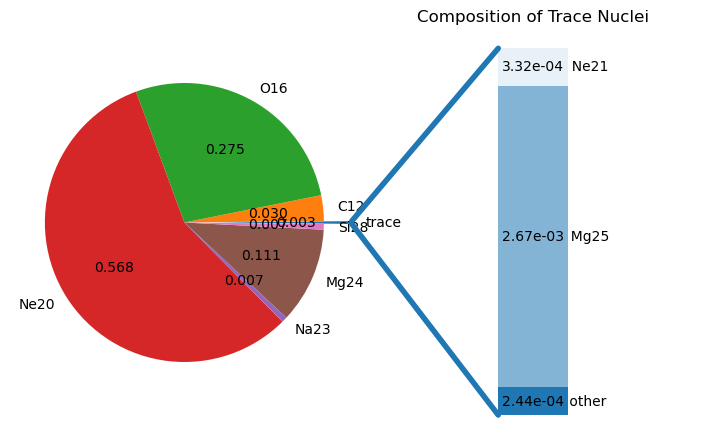

In [9]:
comp = pyna.Composition(net.unique_nuclei)
comp.set_array(X)
fig = comp.plot(trace_threshold=5.e-3)

Now we see that the major products after ${}^{20}\mathrm{Ne}$ are ${}^{24}\mathrm{Mg}$ and then the two Urca nuclei we will focus on: ${}^{23}\mathrm{Na}$ and ${}^{25}\mathrm{Mg}$.